![Federated learning](assets/headers/federated-learning.jpg)

# 04. Federated learning

Four hospitals train one heart-disease model together, and no patient record leaves its hospital.
We compare the shared model with pooling all the data and with each hospital training alone. Then
one hospital sends a corrupted update, and we compare two ways of combining updates.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer

## Setup

Tested with Python 3.11. The next cell installs the package versions used in this notebook.

In [1]:
%pip install --quiet numpy==1.26.4 pandas==2.2.3 scipy==1.13.1 scikit-learn==1.5.0 matplotlib==3.9.4

Note: you may need to restart the kernel to use updated packages.


In [2]:
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.special import expit
from sklearn.model_selection import train_test_split

# Colours used in the figures
NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. Four hospitals, four local datasets

The UCI Heart Disease data were collected at four hospitals: Cleveland, Hungary, Switzerland and
Long Beach. We treat each file as one hospital that keeps its records to itself. The label is 1
when `num > 0`, meaning the patient has heart disease.

All preparation happens inside each hospital, with no information from the others:

- split its own patients into 75% training and 25% test,
- fill missing values with medians of its own training rows (a cholesterol or blood pressure of 0
  is a missing measurement, not a real value),
- scale the ten features with fixed constants that all hospitals agree on beforehand, so that a
  model weight means the same thing everywhere.

In [3]:
UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/"
COLUMNS = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
           "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]


def load_hospital(filename):
    """Download a UCI heart-disease file once, then read it from data/."""
    path = Path("data") / filename
    if not path.exists():
        path.parent.mkdir(exist_ok=True)
        urllib.request.urlretrieve(UCI_URL + filename, path)
    return pd.read_csv(path, names=COLUMNS, na_values="?")

In [4]:
FILES = {"Cleveland": "processed.cleveland.data", "Hungary": "processed.hungarian.data",
         "Switzerland": "processed.switzerland.data", "Long Beach": "processed.va.data"}
FEATURES = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak"]

# Typical values agreed in advance, not computed from anyone's patients
CENTER = np.array([50, 0.5, 2.5, 130, 240, 0.5, 1, 140, 0.5, 1.0])
SCALE = np.array([15, 0.5, 1.5, 30, 100, 0.5, 1, 40, 0.5, 2.0])


def model_input(rows, fill_values):
    """Fill missing values, scale, and add a column of ones for the intercept."""
    scaled = (rows.fillna(fill_values).to_numpy() - CENTER) / SCALE
    return np.column_stack([scaled, np.ones(len(scaled))])


hospitals = {}
for name, filename in FILES.items():
    data = load_hospital(filename)
    features = data[FEATURES].astype(float)
    features[["chol", "trestbps"]] = features[["chol", "trestbps"]].replace(0, np.nan)
    labels = (data.num > 0).astype(int).to_numpy()

    rows = np.arange(len(data))
    train, test = train_test_split(rows, test_size=0.25, random_state=0, stratify=labels)

    # Medians of this hospital's training rows. Switzerland recorded no cholesterol at all,
    # so its median is missing and the agreed CENTER value is used instead.
    fill_values = features.iloc[train].median().fillna(pd.Series(CENTER, index=FEATURES))

    hospitals[name] = {
        "train_X": model_input(features.iloc[train], fill_values), "train_y": labels[train],
        "test_X": model_input(features.iloc[test], fill_values), "test_y": labels[test],
    }

summary = pd.DataFrame(
    [[len(h["train_y"]), len(h["test_y"]), h["train_y"].mean(), h["test_y"].mean()]
     for h in hospitals.values()],
    index=list(hospitals),
    columns=["train", "test", "train disease rate", "test disease rate"],
)
summary.round(3)

,train,test,train disease rate,test disease rate
Cleveland,227,76,0.458,0.461
Hungary,220,74,0.359,0.365
Switzerland,92,31,0.935,0.935
Long Beach,150,50,0.747,0.740


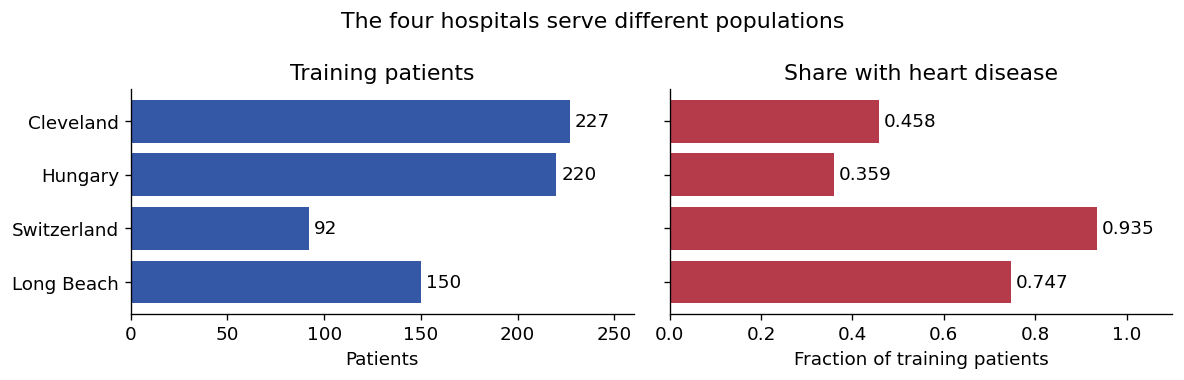

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
left.barh(summary.index, summary["train"], color=BLUE)
left.set(title="Training patients", xlabel="Patients", xlim=(0, 260))
right.barh(summary.index, summary["train disease rate"], color=RED)
right.set(title="Share with heart disease", xlabel="Fraction of training patients", xlim=(0, 1.1))
left.invert_yaxis()
left.bar_label(left.containers[0], padding=3)
right.bar_label(right.containers[0], fmt="%.3f", padding=3)
fig.suptitle("The four hospitals serve different populations")
fig.tight_layout()
plt.show()

Switzerland has the fewest patients, and 93.5% of them have heart disease. In Hungary about one in
three does. A model that fits one hospital may not fit another, and local training at different
hospitals can pull the shared model in different directions (client drift).

## 2. The model, trained and tested locally

The shared model is a logistic regression: one weight per feature plus an intercept, 11 numbers in
total. It predicts heart disease when `X @ w >= 0`. Coded features such as chest-pain type (`cp`)
are used as plain numbers to keep the model small. Training is gradient descent on the mean
logistic loss with a small L2 penalty. Every model in sections 3 to 5 uses this update and starts
from all-zero weights.

Evaluation is local too. Each hospital scores a model on its own test patients and reports only
how many it got right. The server adds up these counts.

In [6]:
ROUNDS, LOCAL_STEPS, LEARNING_RATE, L2 = 80, 5, 0.1, 0.01
N_WEIGHTS = len(FEATURES) + 1  # ten features and the intercept


def gradient(X, y, w):
    """Gradient of the mean logistic loss plus the L2 penalty."""
    penalty = L2 * w
    penalty[-1] = 0  # the intercept is not penalized
    return X.T @ (expit(X @ w) - y) / len(y) + penalty


def gradient_descent(X, y, w, steps):
    for _ in range(steps):
        w = w - LEARNING_RATE * gradient(X, y, w)
    return w


def local_training(hospital, w):
    """A hospital's part of one round: a few gradient steps on its own training patients."""
    return gradient_descent(hospital["train_X"], hospital["train_y"], w, LOCAL_STEPS)


def correct_predictions(hospital, w):
    """Local evaluation: how many of this hospital's test patients the model gets right."""
    predicted = hospital["test_X"] @ w >= 0  # True = heart disease
    return int((predicted == hospital["test_y"]).sum())


def accuracy(w):
    """Accuracy on all test patients, computed from the counts the hospitals report."""
    correct = sum(correct_predictions(h, w) for h in hospitals.values())
    return correct / sum(len(h["test_y"]) for h in hospitals.values())

## 3. Federated averaging (FedAvg)

![One round of federated training](assets/figures/04_federated_round.png)

Each round has four steps. The server sends the current weights to every hospital, each hospital
takes `LOCAL_STEPS` gradient steps on its own patients and sends back its new weights, and the
server combines them. FedAvg combines them with a weighted mean: each hospital counts in
proportion to its number of training patients.

Here is the first round, starting from zero weights.

In [7]:
train_counts = [len(h["train_y"]) for h in hospitals.values()]


def fedavg(updates, counts):
    """Mean of the hospitals' weights, each counted in proportion to its training patients."""
    return sum(n * w for w, n in zip(updates, counts)) / sum(counts)


w = np.zeros(N_WEIGHTS)  # 1. Distribute
# 2-3. Each hospital trains locally and sends back its new weights (plus its patient count)
updates = [local_training(h, w) for h in hospitals.values()]
round_1 = pd.DataFrame(updates, index=list(hospitals), columns=FEATURES + ["intercept"])
round_1.loc["FedAvg"] = fedavg(updates, train_counts)  # 4. Combine

update = updates[0]
print(f"Each hospital sends {update.size} {update.dtype} numbers "
      f"({update.nbytes} bytes) per round.")
round_1.round(3)

Each hospital sends 11 float64 numbers (88 bytes) per round.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,intercept
Cleveland,0.030,0.054,0.048,0.021,0.008,0.017,0.043,-0.061,0.095,0.060,-0.020
Hungary,0.029,0.035,0.061,0.016,0.031,0.069,0.040,-0.043,0.156,0.075,-0.060
Switzerland,0.058,0.135,0.150,0.006,0.000,-0.164,-0.126,-0.087,-0.004,-0.029,0.179
Long Beach,0.088,0.106,0.097,0.028,-0.002,-0.006,-0.040,-0.041,0.085,0.040,0.102
FedAvg,0.046,0.070,0.077,0.019,0.012,0.004,0.002,-0.054,0.099,0.049,0.020


The server sees these 11 numbers and each hospital's patient count (and, during evaluation, how
many test patients it got right), never patient records. After only five steps the hospitals
already disagree. Switzerland, where almost every patient is ill, raises the intercept (a higher
baseline risk), while Hungary lowers it.

Now repeat the round `ROUNDS` times. The function can also make one hospital send a corrupted
update in a chosen round; section 5 uses that.

In [8]:
def federated_training(combine=fedavg, corrupt_site=None, corrupt_round=None, factor=None):
    """Run ROUNDS rounds from zero weights. Return the final weights and the accuracy per round."""
    w, history = np.zeros(N_WEIGHTS), []
    for round_number in range(1, ROUNDS + 1):
        updates = []
        for name, hospital in hospitals.items():
            new_w = local_training(hospital, w)
            if name == corrupt_site and round_number == corrupt_round:
                # Send `factor` times this hospital's real change (negative = opposite direction)
                new_w = w + factor * (new_w - w)
            updates.append(new_w)
        w = combine(updates, train_counts)
        history.append(accuracy(w))
    return w, history


federated_w, federated_history = federated_training()
print(f"Federated model after {ROUNDS} rounds: accuracy {federated_history[-1]:.3f}")

Federated model after 80 rounds: accuracy 0.810


## 4. Federated vs pooled vs each hospital alone

Two kinds of baseline use the same update rule and the same number of gradient steps
(`ROUNDS * LOCAL_STEPS` = 400):

- **Pooled**: all training patients copied to one place. Federated learning exists to avoid this;
  it is here only as a reference point.
- **Hospital only**: each hospital trains on its own patients and does not collaborate
  ("Cleveland only", ...).

All six models are scored on the same 231 test patients, with local evaluation as before.

In [9]:
pooled_X = np.vstack([h["train_X"] for h in hospitals.values()])
pooled_y = np.concatenate([h["train_y"] for h in hospitals.values()])
zeros, steps = np.zeros(N_WEIGHTS), ROUNDS * LOCAL_STEPS

models = {"Pooled": gradient_descent(pooled_X, pooled_y, zeros, steps), "Federated": federated_w}
for name, h in hospitals.items():
    models[f"{name} only"] = gradient_descent(h["train_X"], h["train_y"], zeros, steps)

overall = pd.Series({name: accuracy(w) for name, w in models.items()}, name="accuracy")
overall.round(3).to_frame()

,accuracy
Pooled,0.814
Federated,0.810
Cleveland only,0.810
Hungary only,0.745
Switzerland only,0.580
Long Beach only,0.753


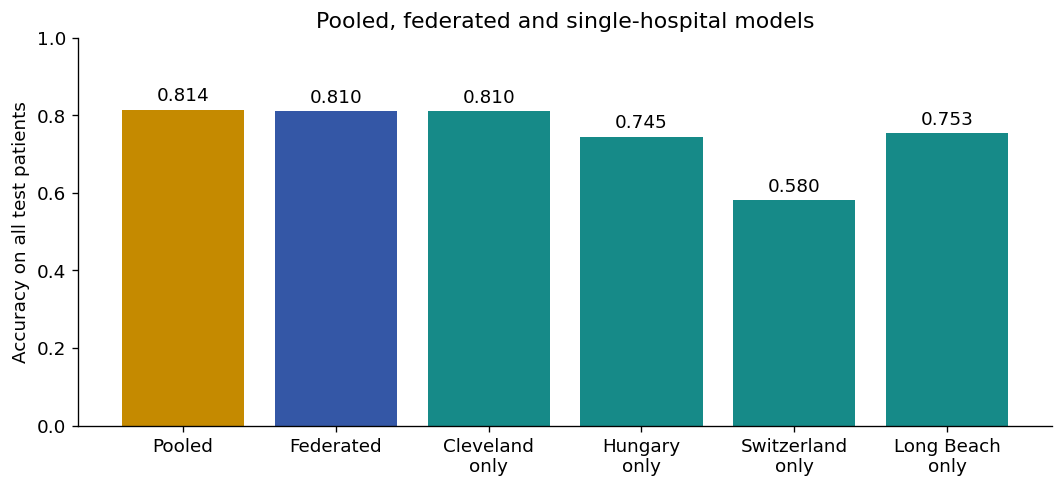

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.2))
colours = [GOLD, BLUE] + [TEAL] * len(hospitals)
bars = ax.bar(overall.index.str.replace(" only", "\nonly"), overall, color=colours)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set(ylim=(0, 1), ylabel="Accuracy on all test patients",
       title="Pooled, federated and single-hospital models")
fig.tight_layout()
plt.show()

The federated model is almost as accurate as the pooled one, and no records moved. Cleveland, the
largest and most balanced site, does as well on its own. The models trained only at Hungary,
Switzerland or Long Beach score lower (0.745, 0.580 and 0.753). An overall score can also hide a
poor result at one site, so look at each hospital separately.

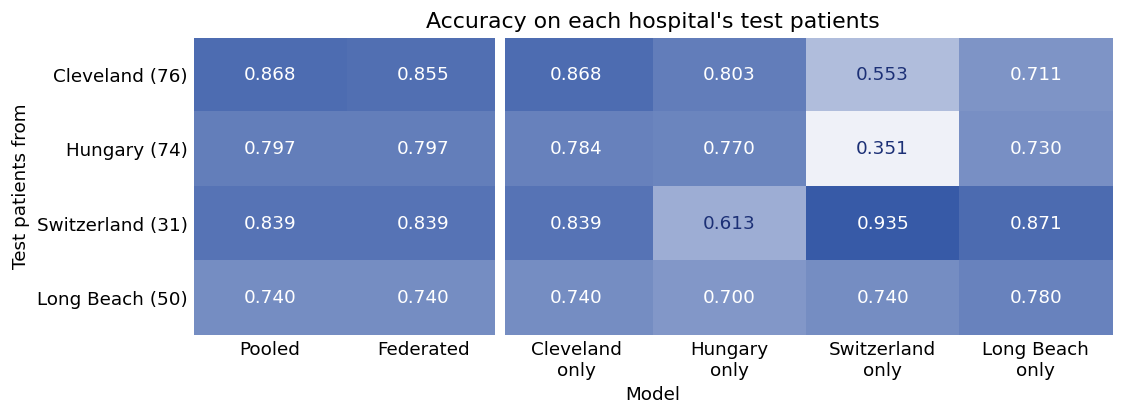

In [11]:
site_accuracy = pd.DataFrame(
    {model: [correct_predictions(h, w) / len(h["test_y"]) for h in hospitals.values()]
     for model, w in models.items()},
    index=list(hospitals),
)

fig, ax = plt.subplots(figsize=(9.5, 3.6))
cmap = LinearSegmentedColormap.from_list("white_to_blue", ["white", BLUE])
ax.imshow(site_accuracy, cmap=cmap, vmin=0.3, vmax=0.95, aspect="auto")
ax.axvline(1.5, color="white", lw=6)  # shared models | single-hospital models
for (i, j), value in np.ndenumerate(site_accuracy.to_numpy()):
    ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="white" if value > 0.65 else NAVY)
ax.set_xticks(range(len(models)), [name.replace(" only", "\nonly") for name in models])
row_labels = [f"{name} ({len(h['test_y'])})" for name, h in hospitals.items()]
ax.set_yticks(range(len(hospitals)), row_labels)
ax.set(xlabel="Model", ylabel="Test patients from",
       title="Accuracy on each hospital's test patients")
ax.tick_params(length=0)
ax.spines[:].set_visible(False)
fig.tight_layout()
plt.show()

The Switzerland-only model gets 93.5% of Swiss patients right but only 35% in Hungary. It
learned that almost everyone is ill, which is true in Switzerland and false in Hungary. The
federated model stays close to the pooled model at every hospital.

On their own patients, three hospitals score higher alone than with the federated model:
Cleveland (0.868 vs 0.855), Switzerland (0.935 vs 0.839) and Long Beach (0.780 vs 0.740). Only
Hungary does better with the federated model (0.797, against 0.770 alone). The shared model gives
up some local fit to get a model that works at every site.

## 5. One corrupted update: weighted mean vs median

A participant can send a bad update, by mistake or on purpose. Here Cleveland, the largest
hospital, behaves normally except in round 5: it sends its change reversed and 20 times larger.
We compare two ways of combining the updates:

- **Weighted mean** (FedAvg): one extreme update moves the mean a lot, and Cleveland has the
  largest weight.
- **Coordinate-wise median**: for each of the 11 weights separately, take the middle value across
  the hospitals. With four hospitals this is the mean of the two middle values, so one extreme
  value cannot drag it far. Patient counts are not used.

In [12]:
def median(updates, counts):
    """Coordinate-wise median of the hospitals' weights. The patient counts are ignored."""
    return np.median(updates, axis=0)


CORRUPT_SITE, CORRUPT_ROUND, FACTOR = "Cleveland", 5, -20
_, mean_corrupted = federated_training(fedavg, CORRUPT_SITE, CORRUPT_ROUND, FACTOR)
_, median_clean = federated_training(median)
_, median_corrupted = federated_training(median, CORRUPT_SITE, CORRUPT_ROUND, FACTOR)
runs = {"Weighted mean, clean": federated_history, "Weighted mean, corrupted": mean_corrupted,
        "Median, clean": median_clean, "Median, corrupted": median_corrupted}
pd.DataFrame({f"round {CORRUPT_ROUND}": [h[CORRUPT_ROUND - 1] for h in runs.values()],
              f"round {ROUNDS}": [h[-1] for h in runs.values()]}, index=list(runs)).round(3)

,round 5,round 80
"Weighted mean, clean",0.792,0.810
"Weighted mean, corrupted",0.558,0.810
"Median, clean",0.788,0.797
"Median, corrupted",0.723,0.797


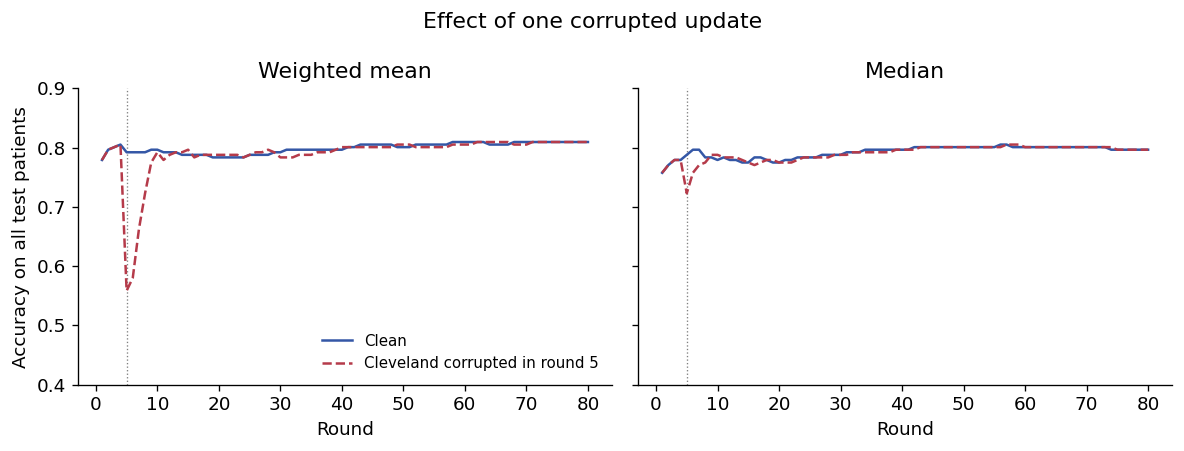

In [13]:
rounds = range(1, ROUNDS + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, method in zip(axes, ["Weighted mean", "Median"]):
    ax.axvline(CORRUPT_ROUND, color="grey", lw=0.8, ls=":")
    ax.plot(rounds, runs[f"{method}, clean"], color=BLUE, label="Clean")
    ax.plot(rounds, runs[f"{method}, corrupted"], color=RED, ls="--",
            label=f"{CORRUPT_SITE} corrupted in round {CORRUPT_ROUND}")
    ax.set(title=method, xlabel="Round")
axes[0].set(ylabel="Accuracy on all test patients", ylim=(0.4, 0.9))
axes[0].legend(loc="lower right", fontsize=9, frameon=False)
fig.suptitle("Effect of one corrupted update")
fig.tight_layout()
plt.show()

With the weighted mean, one message drops accuracy from 0.792 to 0.558. The median drops much
less, from 0.788 to 0.723. Both recover within a few rounds because Cleveland goes back to normal
updates. The median has a cost too: without any corruption it ends at 0.797 instead of 0.810.
One reason: it ignores patient counts, so Switzerland's 92 patients get the same say as
Cleveland's 227.

Keeping records local does not make the updates private. The numbers a hospital sends are computed
from its patients and can leak information about them. Secure aggregation and differential
privacy protect against this, and neither is used here.

## Optional: FedProx and FedAdam

Two common variants of FedAvg change different parts of the round:

- **FedProx** changes local training. Each hospital adds the penalty
  `mu/2 * ||w - w_global||²` to its loss, which pulls its weights back towards the model it
  received. This limits client drift.
- **FedAdam** changes the server step. The server treats the averaged change
  `fedavg(updates) - w` like a gradient step and applies Adam to it, keeping running means of the
  change and of its square.

Hospitals, rounds and local steps stay the same. `PROX_MU` and the Adam settings below were set
once and not tuned.

In [14]:
PROX_MU = 0.5
ADAM_ETA, ADAM_BETA1, ADAM_BETA2, ADAM_TAU = 0.1, 0.9, 0.99, 1e-3


def fedprox_local_training(hospital, w_global):
    """Local gradient steps with an extra pull towards this round's global weights."""
    X, y, w = hospital["train_X"], hospital["train_y"], w_global
    for _ in range(LOCAL_STEPS):
        w = w - LEARNING_RATE * (gradient(X, y, w) + PROX_MU * (w - w_global))
    return w


def fedprox_training():
    w, history = np.zeros(N_WEIGHTS), []
    for _ in range(ROUNDS):
        updates = [fedprox_local_training(h, w) for h in hospitals.values()]
        w = fedavg(updates, train_counts)
        history.append(accuracy(w))
    return history


def fedadam_training():
    w, history = np.zeros(N_WEIGHTS), []
    m, v = np.zeros(N_WEIGHTS), np.zeros(N_WEIGHTS)  # running means of the change and its square
    for t in range(1, ROUNDS + 1):
        updates = [local_training(h, w) for h in hospitals.values()]
        change = fedavg(updates, train_counts) - w
        m = ADAM_BETA1 * m + (1 - ADAM_BETA1) * change
        v = ADAM_BETA2 * v + (1 - ADAM_BETA2) * change**2
        # Adam's bias correction (the step count is offset by one, which only changes early steps)
        step = ADAM_ETA * np.sqrt(1 - ADAM_BETA2 ** (t + 1)) / (1 - ADAM_BETA1 ** (t + 1))
        w = w + step * m / (np.sqrt(v) + ADAM_TAU)
        history.append(accuracy(w))
    return history


method_runs = {"FedAvg": federated_history, "FedProx": fedprox_training(),
               "FedAdam": fedadam_training()}
final_accuracy = {name: history[-1] for name, history in method_runs.items()}
pd.Series(final_accuracy, name=f"accuracy after {ROUNDS} rounds").round(4).to_frame()

,accuracy after 80 rounds
FedAvg,0.8095
FedProx,0.8095
FedAdam,0.8268


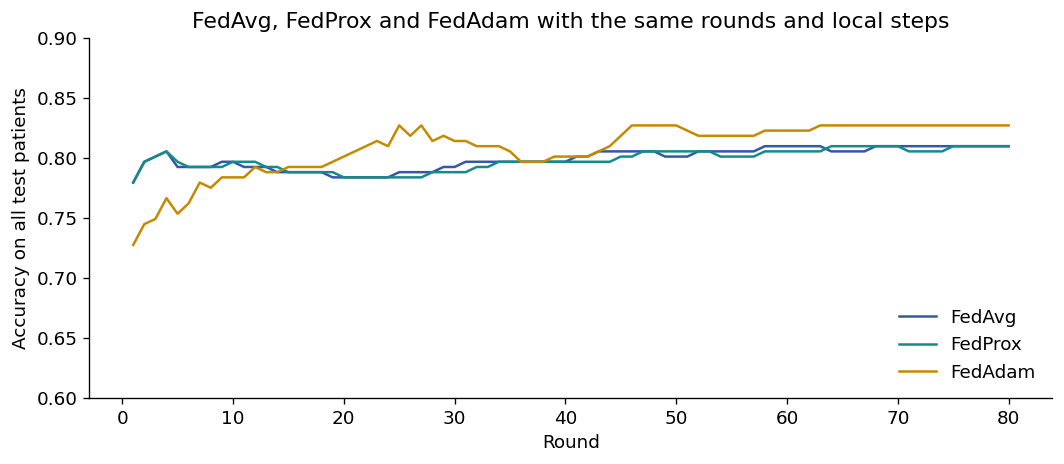

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
for (name, history), colour in zip(method_runs.items(), [BLUE, TEAL, GOLD]):
    ax.plot(rounds, history, color=colour, label=name)
ax.set(xlabel="Round", ylabel="Accuracy on all test patients", ylim=(0.6, 0.9),
       title="FedAvg, FedProx and FedAdam with the same rounds and local steps")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()

FedProx ends where FedAvg does, and FedAdam a little higher. This is one run on one split. To
compare methods fairly, tune each one on a validation split and change one setting at a time.

## Experiments

1. In section 2, set `ROUNDS = 8` and `LOCAL_STEPS = 50` (the same 400 steps in total) and rerun
   from there. With more local work between rounds, what happens to the federated model?
2. Change `CORRUPT_SITE` to `"Switzerland"` or `FACTOR` to `-100`, and compare the weighted mean
   and the median again.
3. Limit the size of each update: in `federated_training`, scale down any change `new_w - w`
   whose norm is above 0.5 before it is combined (clean changes here stay below 0.4). How much
   does the weighted mean drop in round 5 now?
4. Remove Switzerland from `FILES` and rerun. How do the other hospitals' results change?

**References:** [McMahan et al., FedAvg (2017)](https://arxiv.org/abs/1602.05629) ·
[Li et al., FedProx (2020)](https://arxiv.org/abs/1812.06127) ·
[Reddi et al., Adaptive Federated Optimization (2021)](https://arxiv.org/abs/2003.00295) ·
[Flower framework](https://flower.ai/docs/framework/) ·
[UCI Heart Disease data](https://archive.ics.uci.edu/dataset/45/heart+disease)